done


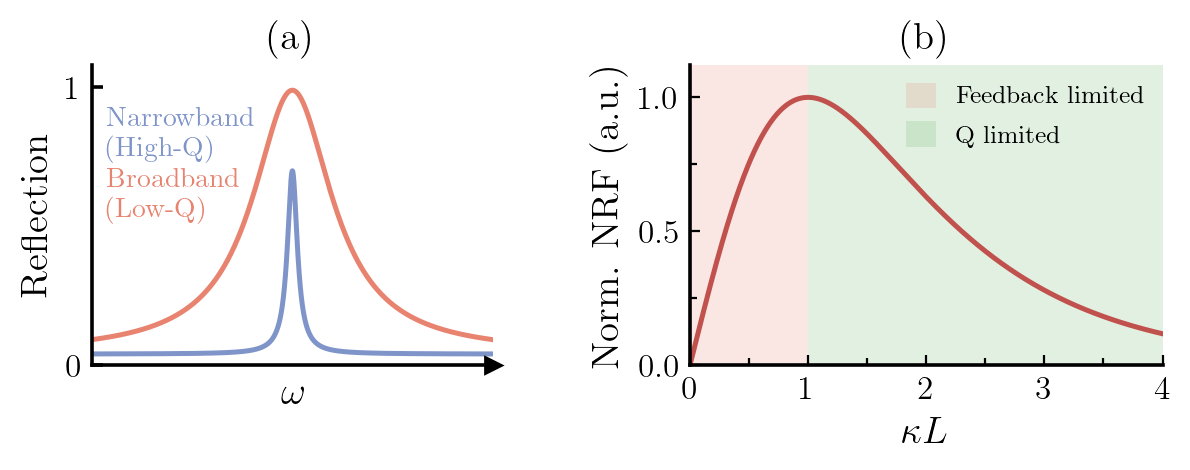

In [12]:
# ============================================================
# plot_schematic.py
# (a) Narrowband/broadband reflection schematic.
# (b) Normalised NRF vs kappa*L with feedback/Q-limited shading.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator

# ── Plotting parameters ────────────────────────────────────────────────────────
maj_tick_width = 0.8
min_tick_width = 0.8
plot_params = {
    "figure.dpi": "200",
    "axes.labelsize": 14,
    "axes.linewidth": 1.5,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.title_fontsize": 11,
    "legend.fontsize": 11,
    "xtick.major.size": 3.5,
    "xtick.major.width": maj_tick_width,
    "xtick.minor.size": 2.5,
    "xtick.minor.width": min_tick_width,
    "ytick.major.size": 3.5,
    "ytick.major.width": maj_tick_width,
    "ytick.minor.size": 2.5,
    "ytick.minor.width": min_tick_width,
    "font.family": "Times New Roman",
    "text.usetex": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pgf.texsystem": "pdflatex",
    "pgf.rcfonts": False,
}
plt.rcParams.update(plot_params)

# ── Panel (a): Lorentzian reflection curves ────────────────────────────────────
def lorentzian(w, gamma, amp, baseline):
    return baseline + amp / (1 + (w / gamma) ** 2)

w        = np.linspace(-10, 10, 3000)
baseline = 0.04
narrow   = lorentzian(w, gamma=0.30, amp=0.66, baseline=baseline)
broad    = lorentzian(w, gamma=2.40, amp=0.95, baseline=baseline)

# ── Panel (b): NRF computation ────────────────────────────────────────────────
# With constant K the formula NRF = [1 + K·L_ext·tanh(κL)]² is monotonically
# increasing — it never peaks.  Physically K is proportional to the grating
# *field transmissivity* sech(κL): a very strong grating reflects most of the
# intracavity field back, so less light reaches the external reflector and the
# feedback rate drops.  The effective coupling term therefore becomes:
#
#   K_eff ∝ sech(κL)  →  NRF ∝ [sech(κL)·tanh(κL)]²
#
# The product sech(κL)·tanh(κL) = sinh(κL)/cosh²(κL) has its natural maximum at
# κL0 = arccosh(√2) ≈ 0.88. To place the peak at the physically-motivated point
# κL = 1 (rather than at κL0), the argument is rescaled by
#
#   s = 1 / κL0
#
# so that NRF ∝ [sech(κL/s)·tanh(κL/s)]² peaks exactly at κL = s·κL0 = 1.
# Normalising to unit peak: NRF_norm = 2·sech(κL/s)·tanh(κL/s).

kL0      = np.arccosh(np.sqrt(2))     # original (unscaled) peak location ≈ 0.8814
s        = 1.0 / kL0                  # rescaling factor so the new peak sits at κL = 1

kL       = np.linspace(0, 4, 2000)
NRF_raw  = np.tanh(kL / s) / np.cosh(kL / s)   # sech(κL/s)·tanh(κL/s)
NRF_norm = NRF_raw / NRF_raw.max()              # normalise to 1

kL_peak  = kL[np.argmax(NRF_raw)]               # ≈ 1.0

# ── Figure layout (identical geometry to original) ────────────────────────────
fig = plt.figure(figsize=(6.3, 3))
gs  = GridSpec(1, 2, width_ratios=[0.85, 1], wspace=0.45,
               left=0.08, right=0.93, top=0.68, bottom=0.18)

ax_lw    = fig.add_subplot(gs[0])
ax_spare = fig.add_subplot(gs[1])

# ── Left panel (a): reflection schematic ─────────────────────────────────────
ax_lw.plot(w, broad,  color='#e8836f', linewidth=1.8)
ax_lw.plot(w, narrow, color='#7f95c9', linewidth=1.8)

ax_lw.set_xlim(-10, 10)
ax_lw.set_ylim(0, 1.08)
ax_lw.set_xticks([])
ax_lw.set_yticks([0, 1])
ax_lw.set_yticklabels(['0', '1'])

ax_lw.spines['top'].set_visible(False)
ax_lw.spines['right'].set_visible(False)
ax_lw.spines['left'].set_linewidth(1.3)
ax_lw.spines['bottom'].set_linewidth(1.3)
ax_lw.tick_params(axis='y', length=4, width=1.3)
ax_lw.tick_params(axis='x', length=0)

# Arrowhead at right end of omega axis
ax_lw.plot(1, 0, marker='>', color='black', markersize=6, clip_on=False,
           transform=ax_lw.get_yaxis_transform())

ax_lw.set_xlabel(r'$\omega$')
ax_lw.set_ylabel('Reflection')

ax_lw.text(-9.3, 0.93, 'Narrowband', color='#7f95c9', ha='left', va='top')
ax_lw.text(-9.3, 0.83, '(High-Q)',   color='#7f95c9', ha='left', va='top')
ax_lw.text(-9.3, 0.71, 'Broadband',  color='#e8836f', ha='left', va='top')
ax_lw.text(-9.3, 0.61, '(Low-Q)',    color='#e8836f', ha='left', va='top')

# Panel tag — data coords, matching original
#ax_lw.text(-12, 1.32, '(a)', fontsize=13, fontweight='bold', va='bottom')
ax_lw.set_title('(a)')
# ── Right panel (b): NRF vs kappa·L ─────────────────────────────────────────
# Shaded regime regions — now labelled directly for the legend instead of
# free-floating text boxes.
ax_spare.axvspan(0,       kL_peak, color='#e8836f', alpha=0.20, lw=0,
                  label='Feedback limited')
ax_spare.axvspan(kL_peak, 4,       color='#6db86d', alpha=0.20, lw=0,
                  label='Q limited')
ax_spare.set_title('(b)')
# NRF curve
ax_spare.plot(kL, NRF_norm, color='#c0514c', linewidth=1.8)

# Legend (replaces the old in-axes text labels)
ax_spare.legend(loc='upper right', frameon=False, fontsize=9,
                 handlelength=1.2, handleheight=1.2, borderaxespad=0.3)

# Axes
ax_spare.set_xlim(0, 4)
ax_spare.set_ylim(0, 1.12)
ax_spare.set_xticks([0, 1, 2, 3, 4])
ax_spare.set_yticks([0, 0.5, 1])
ax_spare.xaxis.set_minor_locator(AutoMinorLocator(2))
ax_spare.yaxis.set_minor_locator(AutoMinorLocator(2))

ax_spare.set_xlabel(r'$\kappa L$')
ax_spare.set_ylabel('Norm. NRF (a.u.)')

ax_spare.spines['top'].set_visible(False)
ax_spare.spines['right'].set_visible(False)
ax_spare.spines['left'].set_linewidth(1.3)
ax_spare.spines['bottom'].set_linewidth(1.3)
ax_spare.tick_params(axis='both', which='major', length=3.5, width=maj_tick_width)
ax_spare.tick_params(axis='both', which='minor', length=2.5, width=min_tick_width)

# Panel tag — axes coords, matching heatmap panel style
#ax_spare.text(-0.15, 1.22, '(b)', transform=ax_spare.transAxes,
#              fontsize=13, fontweight='bold', va='bottom')

# ── Save ──────────────────────────────────────────────────────────────────────
OUT_PATH = (r'C:\Users\josep\Documents\MRes mini-project 2\Figures'
            r'\Ultra-stable-lasers-and-photonic-integrated-circuits-for-secure-communications'
            r'\content\Figures\pgf_figures\exp_linewidth.pgf')
plt.savefig(OUT_PATH, dpi=300, bbox_inches='tight')
print('done')